В качестве набора данных мы будем использовать набор данных по обнаружению присутствия людей в помещении

задача является очень актуальной для создания "умных зданий", которые выполняют все требования по кондиционированию воздуха, температурным условиям, но при этом экономят электроэнергию в том случае, если людей в помещении нет.
Датасет состоит из трех файлов:
* datatraining.txt - обучающая выборка (в этом примере используется только данный файл)
* datatest.txt - тестовая выборка
* datatest2.txt - тестовая выборка большего размера
Каждый файл содержит следующие колонки:
* date - дата-время в формате ГОД-МЕСЯЦ-ДЕНЬ ЧАСЫ:МИНУТЫ:СЕКУНДЫ. Набор данных содержит данные с интервалом измерения в минуту.
* Temperature - температура в градусах Цельсия.
* Humidity - относительная влажность в %.
* Light - освещенность в Люксах.
* CO2 - концентрация углекислого газа в миллионных долях.
* HumidityRatio - величина, производная от температуры и относительной влажности.
* Occupancy - целевой признак. Если в помещении находятся люди то 1, иначе 0.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")


In [ ]:
# Будем анализировать данные только на обучающей выборке
data = pd.read_csv('/content/drive/MyDrive/ML DL datasets/Task1/datatraining.txt', sep = ',')

In [ ]:
data.head()

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
1,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1
2,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1
3,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1
4,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1
5,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1


In [ ]:
data.shape
total_cnt = data.shape[0]
total_col = data.shape[1]
print(f'Всего строк: {total_cnt}')
print(f'Всего колонок: {total_col}')

Всего строк: 8143
Всего колонок: 7


In [ ]:
data.columns

Index(['date', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio',
       'Occupancy'],
      dtype='object')

In [ ]:
data.dtypes

,0
date,object
Temperature,float64
Humidity,float64
Light,float64
CO2,float64
HumidityRatio,float64
Occupancy,int64


In [ ]:
# Проверим наличие пустых значений
# Цикл по колонкам датасета
for col in data.columns:
  temp_null_count = data[data[col].isnull()].shape[0]
  print('{} - {}'.format(col, temp_null_count))

date - 0
Temperature - 0
Humidity - 0
Light - 0
CO2 - 0
HumidityRatio - 0
Occupancy - 0


In [ ]:
# Общее количество пустых значений в датасете
total_null = data.isnull().sum().sum()
print(f"Всего пустых значений: {total_null}")

# Количество пустых значений по столбцам
null_by_column = data.isnull().sum()
print("Пустые значения по столбцам:")
print(null_by_column)

Всего пустых значений: 0
Пустые значения по столбцам:
date             0
Temperature      0
Humidity         0
Light            0
CO2              0
HumidityRatio    0
Occupancy        0
dtype: int64


In [ ]:
data.describe()

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
count,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000
mean,20.619084,25.731507,119.519375,606.546243,0.003863,0.212330
std,1.016916,5.531211,194.755805,314.320877,0.000852,0.408982
min,19.000000,16.745000,0.000000,412.750000,0.002674,0.000000
25%,19.700000,20.200000,0.000000,439.000000,0.003078,0.000000
50%,20.390000,26.222500,0.000000,453.500000,0.003801,0.000000
75%,21.390000,30.533333,256.375000,638.833333,0.004352,0.000000
max,23.180000,39.117500,1546.333333,2028.500000,0.006476,1.000000


In [ ]:
# Определим уникальные значения для целевого признака
# Целевой признак является бинарным и содержит только значения 0 и 1.
data['Occupancy'].unique()

array([1, 0])

Диаграмма рассеяния
Позволяет построить распределение двух колонок данных и визуально обнаружить наличие зависимости. Не предполагается, что значения упорядочены (например, по времени).

<Axes: xlabel='Humidity', ylabel='HumidityRatio'>

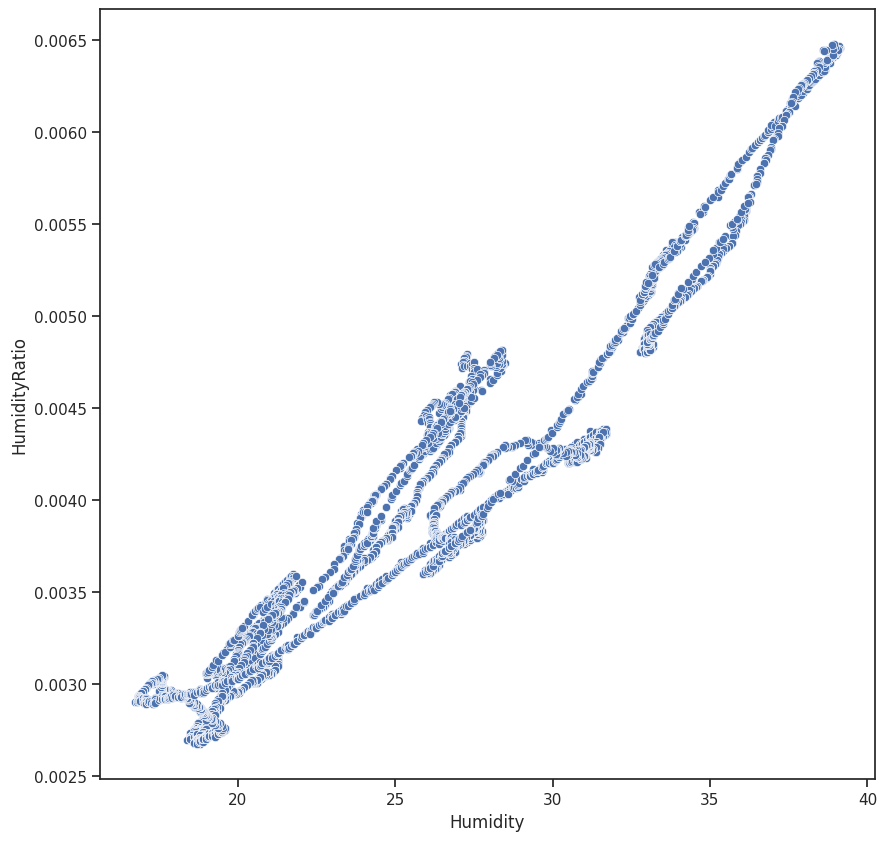

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, x='Humidity', y='HumidityRatio', data=data)

между полями Humidity и HumidityRatio пристутствует почти линейная зависимость.

<Axes: xlabel='Humidity', ylabel='HumidityRatio'>

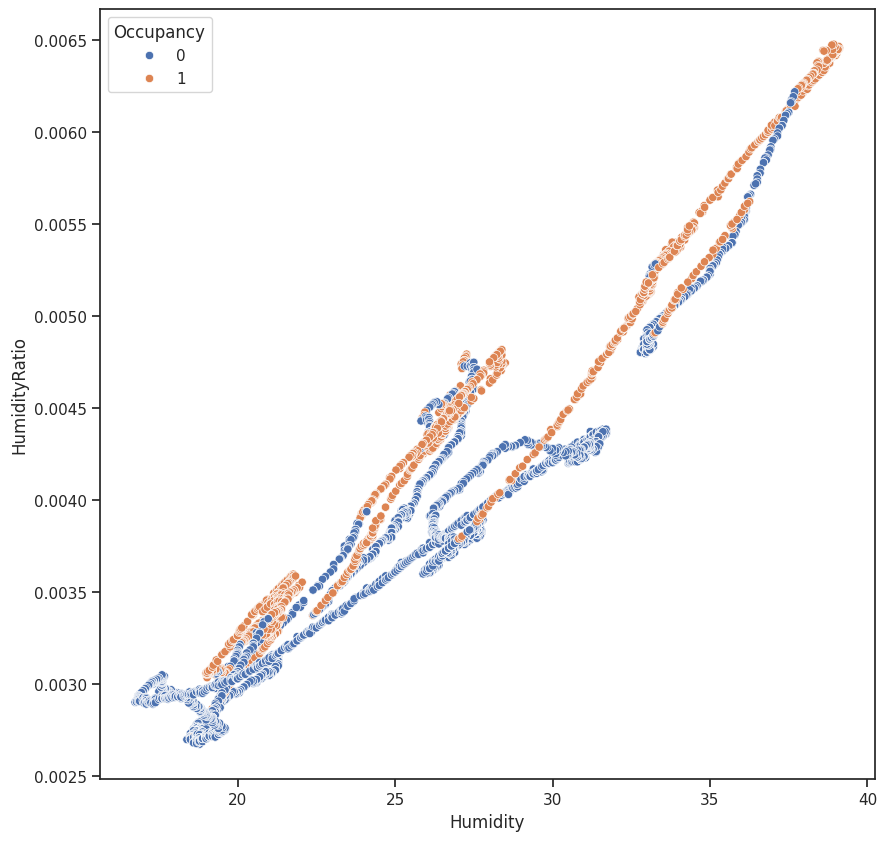

In [ ]:
#Посмотрим насколько на эту зависимость влияет целевой признак.
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, x='Humidity', y='HumidityRatio', data=data, hue='Occupancy')

/tmp/ipython-input-2502456589.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Humidity'])


<Axes: xlabel='Humidity', ylabel='Density'>

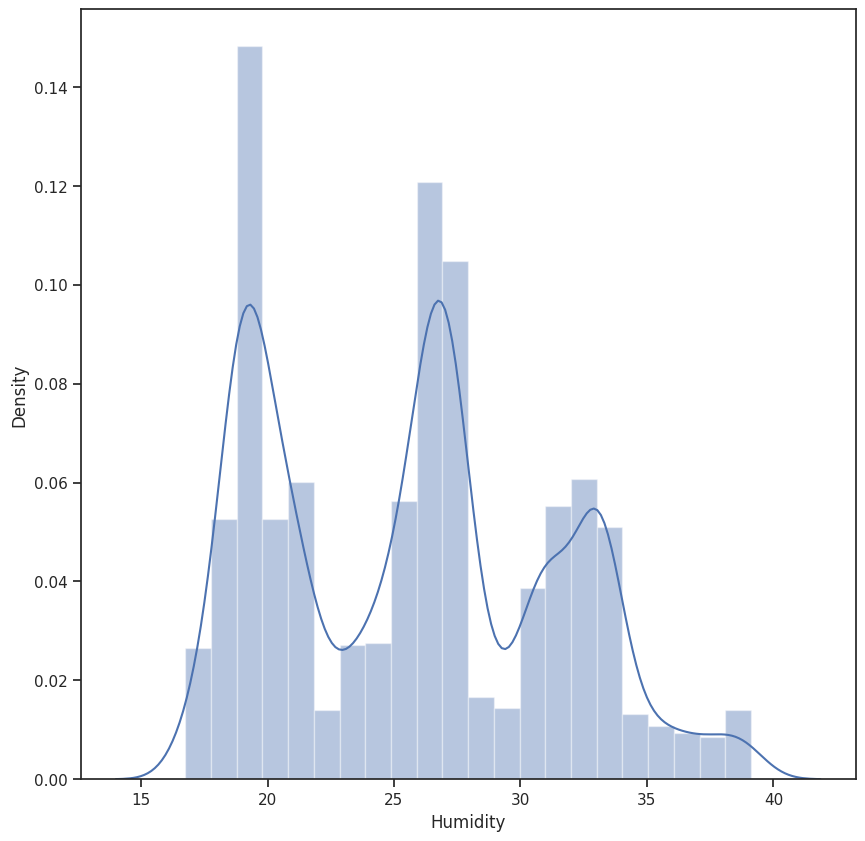

In [ ]:
#Гистограмма
#Позволяет оценить плотность вероятности распределения данных.
fig, ax = plt.subplots(figsize=(10,10))
sns.distplot(data['Humidity'])

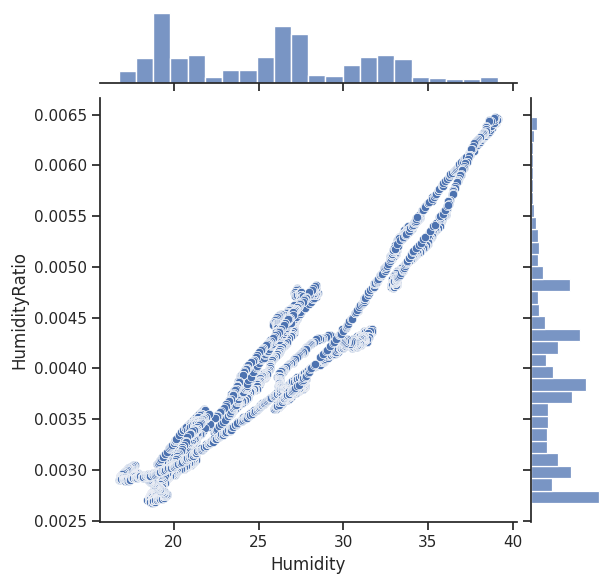

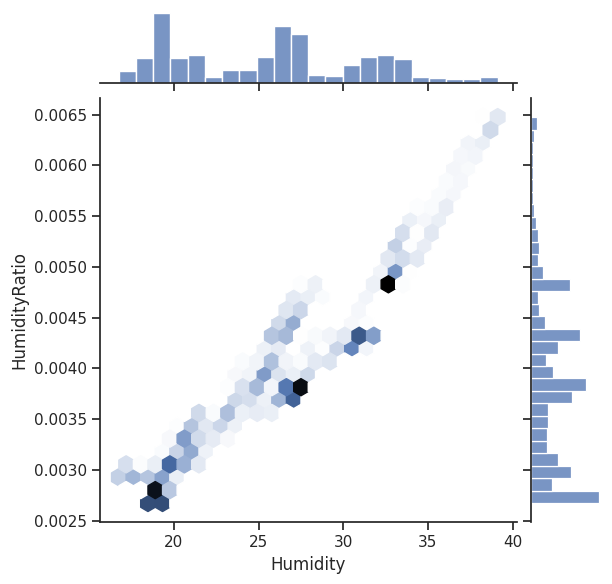

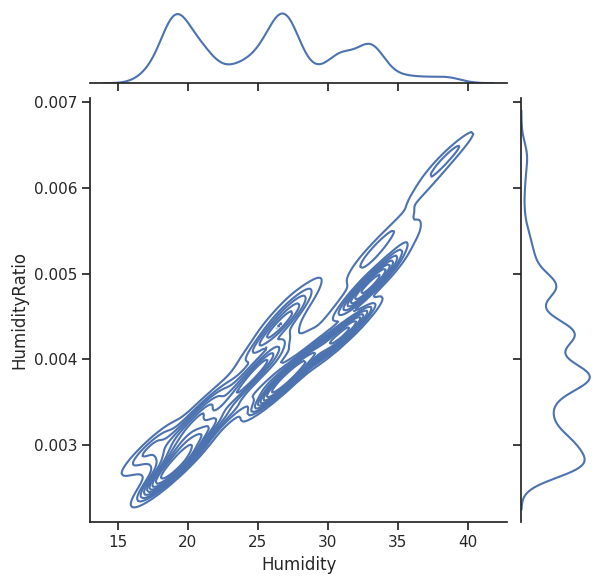

In [ ]:
# Jointplot
# Комбинация гистограмм и диаграмм рассеивания.
sns.jointplot(x='Humidity', y='HumidityRatio', data=data)
sns.jointplot(x='Humidity', y='HumidityRatio', data=data, kind="hex")
sns.jointplot(x='Humidity', y='HumidityRatio', data=data, kind="kde")

Парные диаграммы
Комбинация гистограмм и диаграмм рассеивания для всего набора данных.
Выводится матрица графиков. На пересечении строки и столбца, которые соответстуют двум показателям, строится диаграмма рассеивания. В главной диагонали матрицы строятся гистограммы распределения соответствующих показателей.

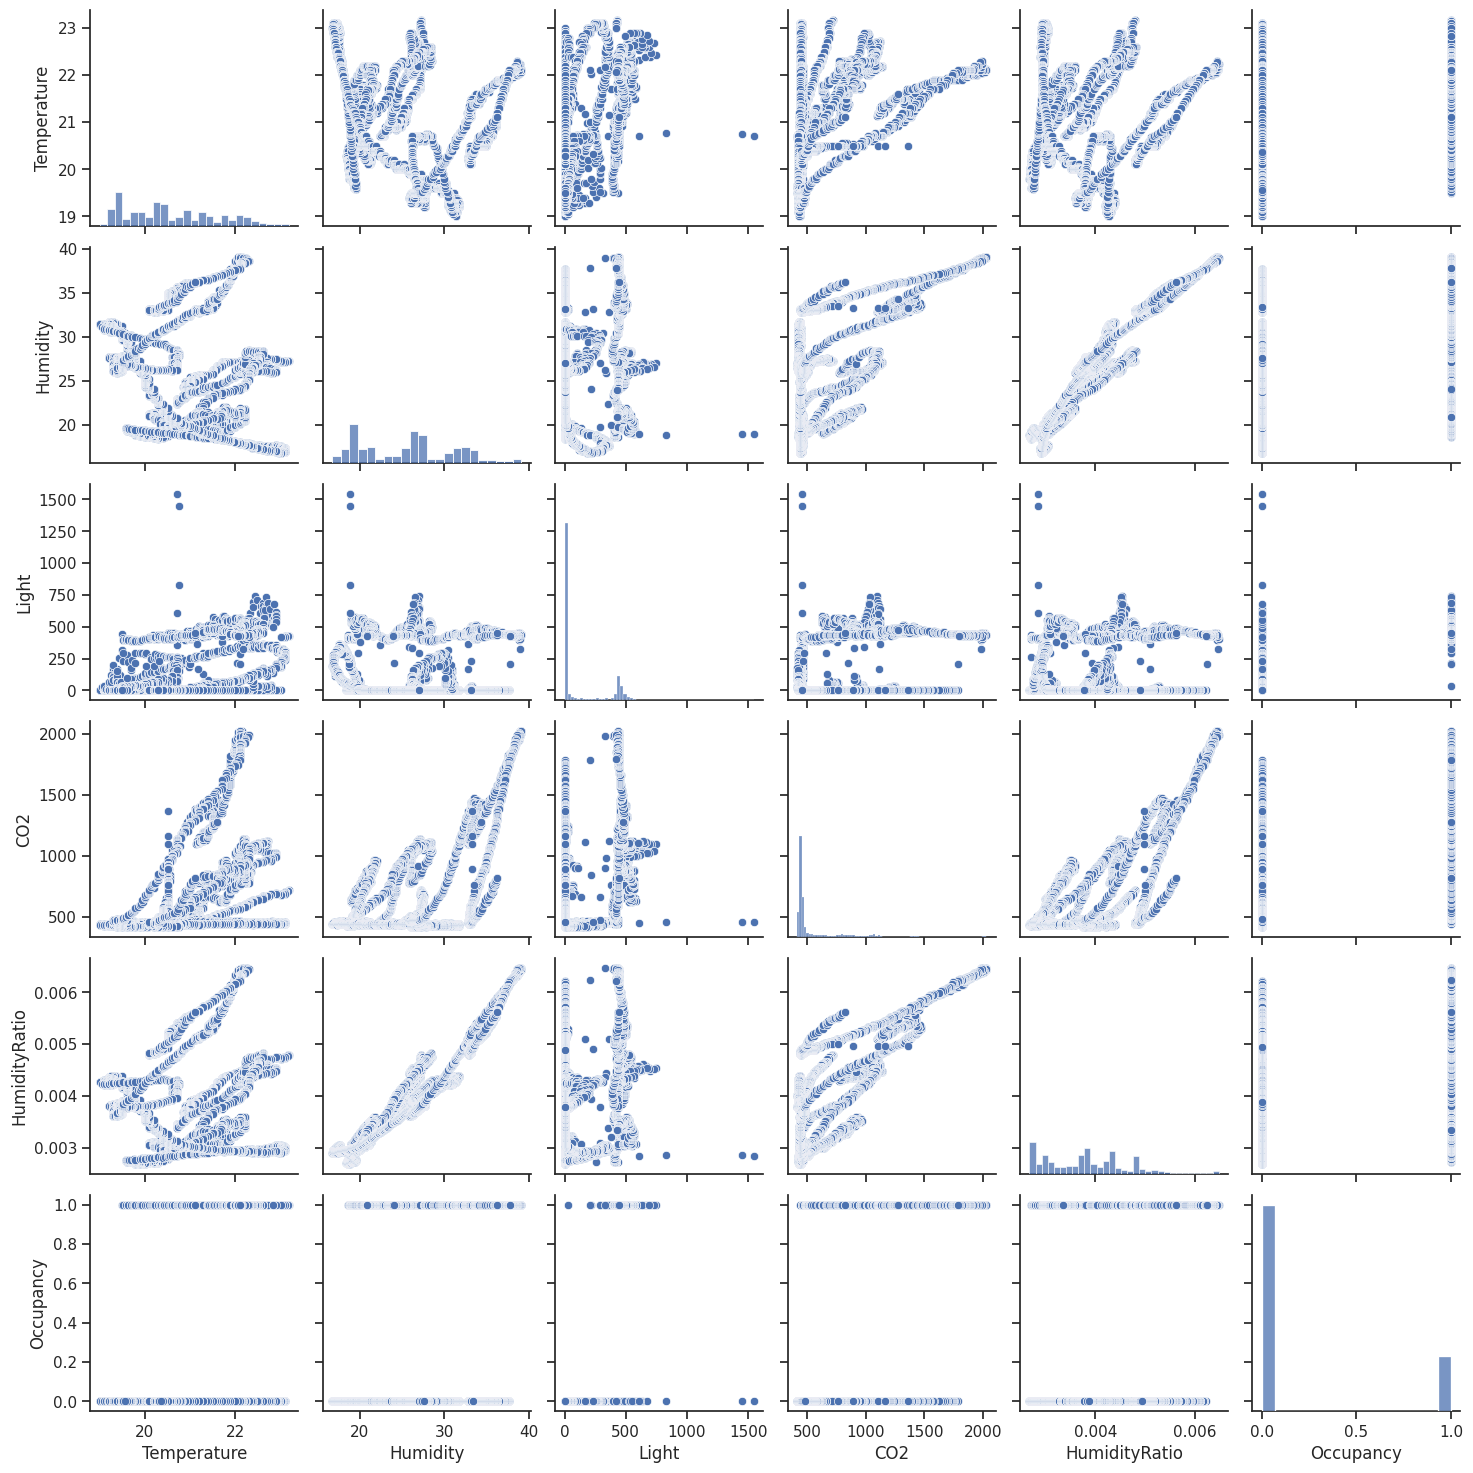

In [ ]:
sns.pairplot(data)

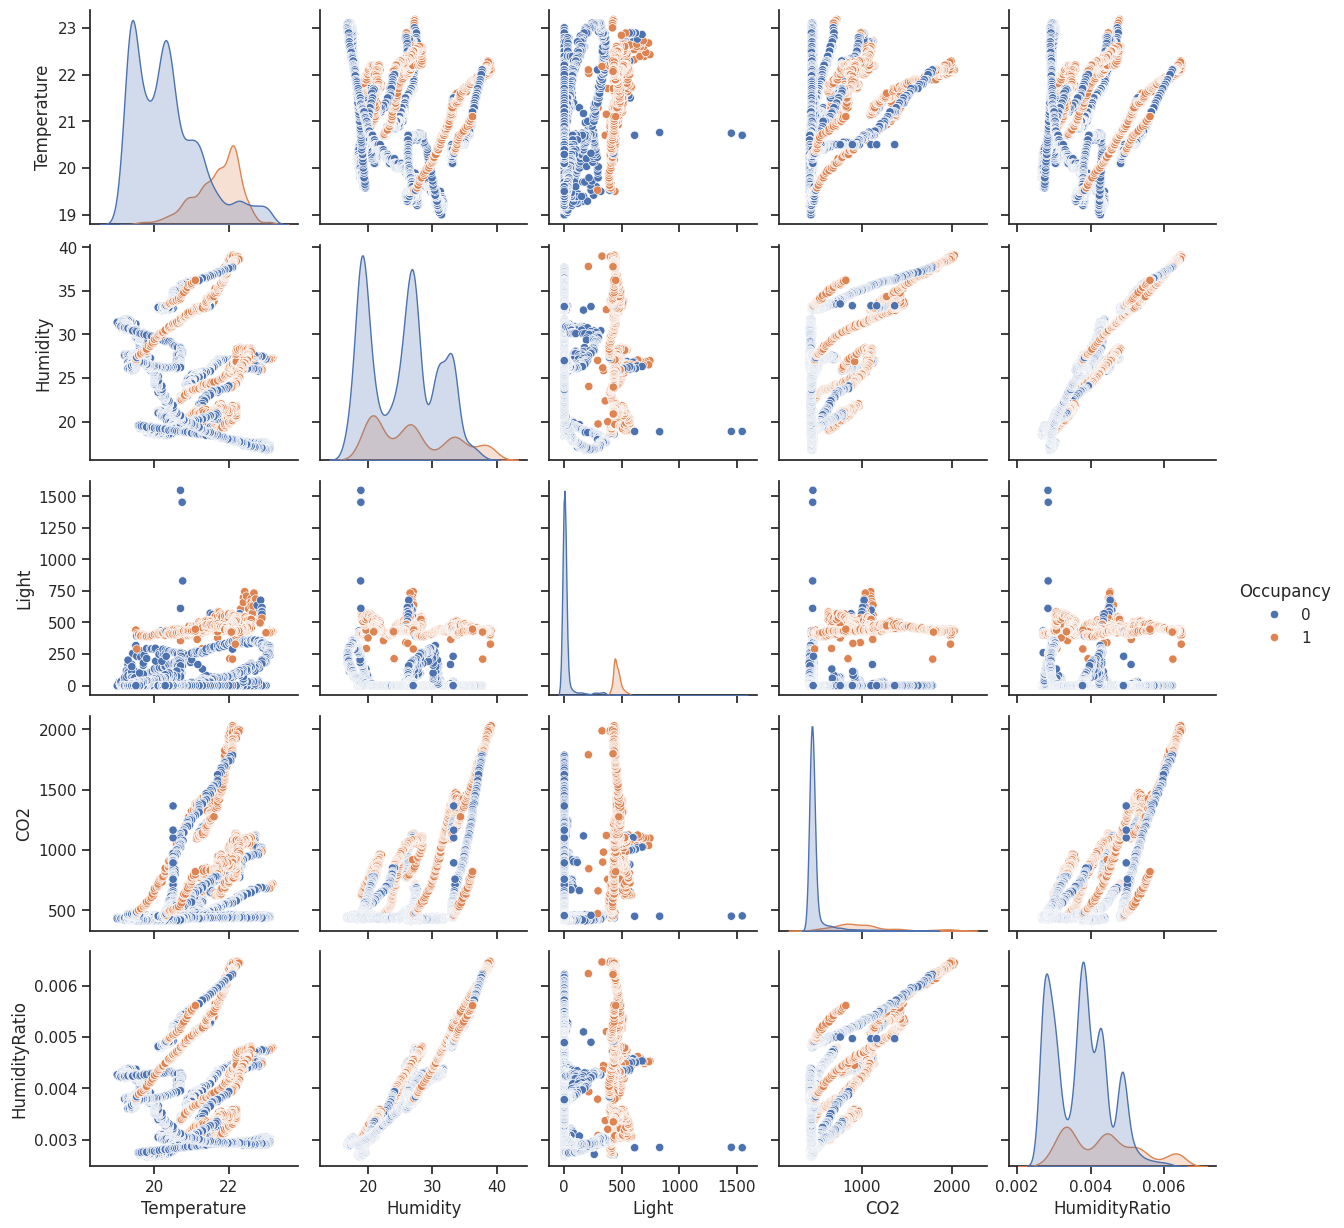

In [ ]:
# С помощью параметра "hue" возможна группировка по значениям какого-либо признака.
sns.pairplot(data, hue="Occupancy")

<Axes: xlabel='Humidity'>

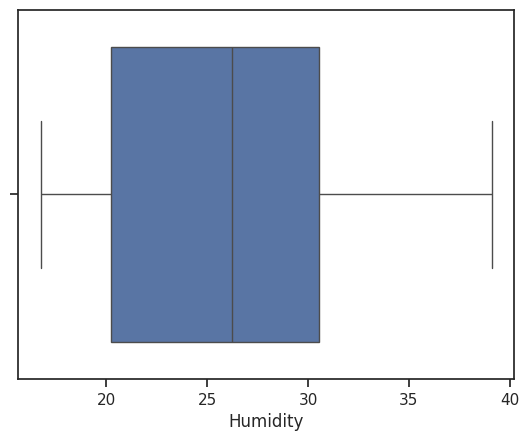

In [ ]:
#Ящик с усами
#Отображает одномерное распределение вероятности.
sns.boxplot(x=data['Humidity'])

<Axes: ylabel='Humidity'>

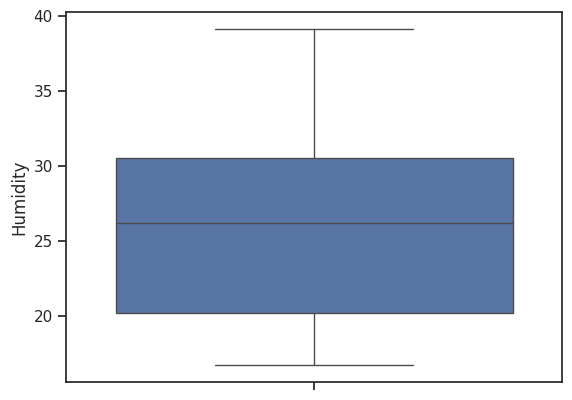

In [ ]:
# По вертикали
sns.boxplot(y=data['Humidity'])

<Axes: xlabel='Occupancy', ylabel='Humidity'>

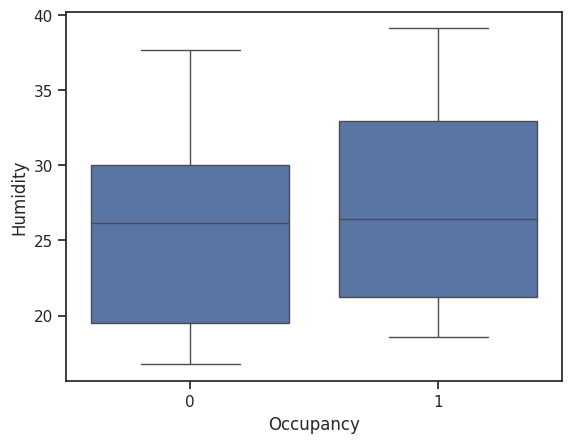

In [ ]:
# Распределение параметра Humidity сгруппированные по Occupancy.
sns.boxplot(x='Occupancy', y='Humidity', data=data)

/tmp/ipython-input-2705052706.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Humidity'], ax=ax[1])


<Axes: xlabel='Humidity', ylabel='Density'>

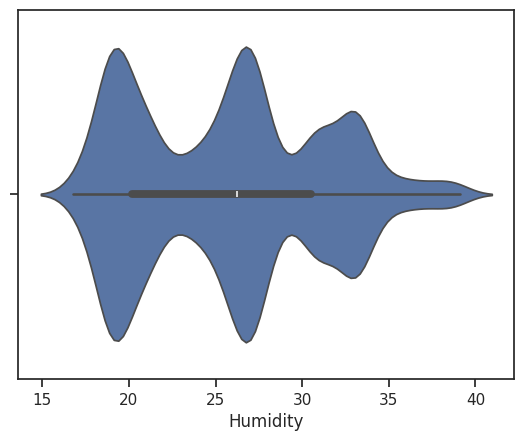

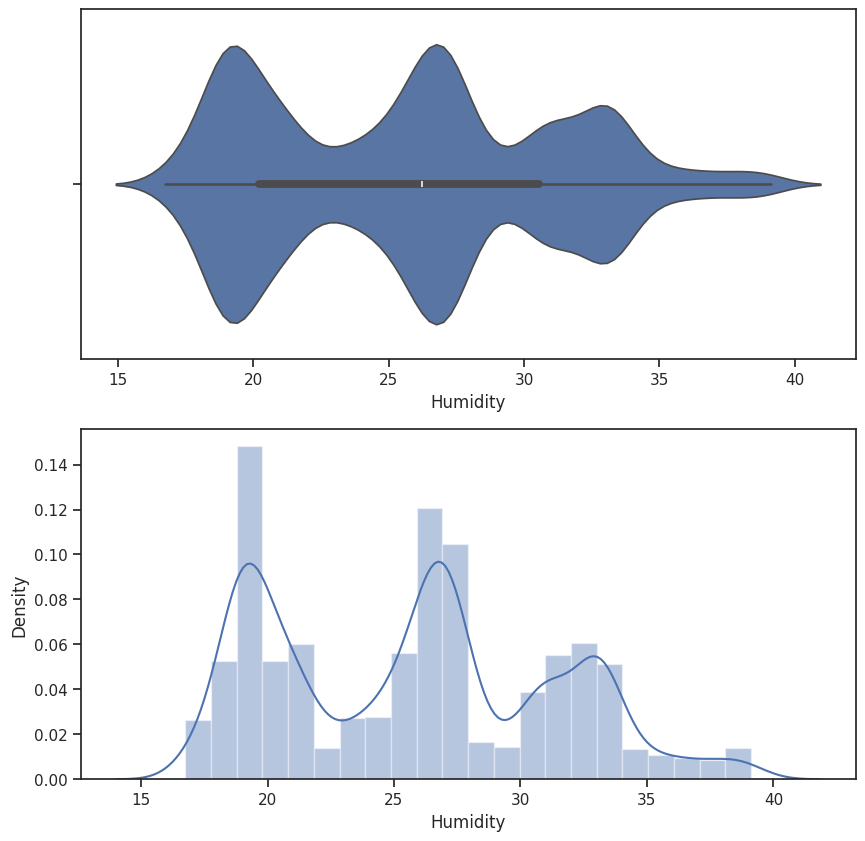

In [ ]:
#Violin plot
#Похоже на предыдущую диаграмму, но по краям отображаются распределения плотности
sns.violinplot(x=data['Humidity'])
fig, ax = plt.subplots(2, 1, figsize=(10,10))
sns.violinplot(ax=ax[0], x=data['Humidity'])
sns.distplot(data['Humidity'], ax=ax[1])

Из приведенных графиков видно, что violinplot действительно показывает распределение плотности.

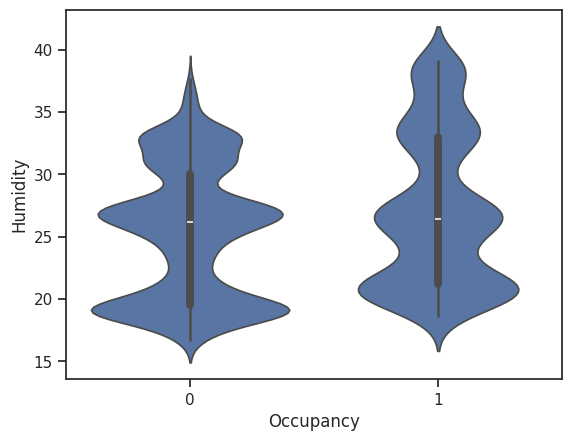

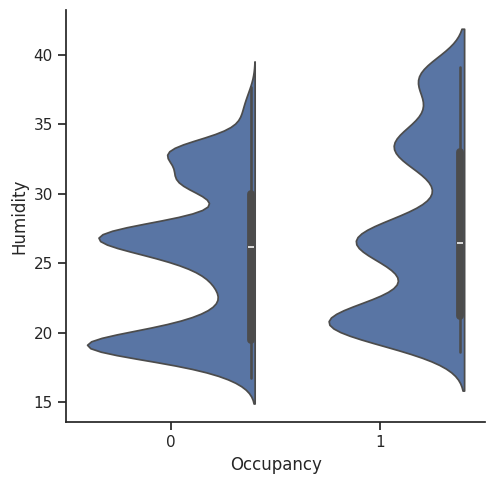

In [ ]:
# Распределение параметра Humidity сгруппированные по Occupancy.
sns.violinplot(x='Occupancy', y='Humidity', data=data)
sns.catplot(y='Humidity', x='Occupancy', data=data, kind="violin", split=True)

4) Информация о корреляции признаков
Проверка корреляции признаков позволяет решить две задачи:
- Понять какие признаки (колонки датасета) наиболее сильно коррелируют с целевым признаком (в нашем примере это колонка "Occupancy"). Именно эти признаки будут наиболее информативными для моделей машинного обучения. Признаки, которые слабо коррелируют с целевым признаком, можно попробовать исключить из построения модели, иногда это повышает качество модели. Нужно отметить, что некоторые алгоритмы машинного обучения автоматически определяют ценность того или иного признака для построения модели.
- Понять какие нецелевые признаки линейно зависимы между собой. Линейно зависимые признаки, как правило, очень плохо влияют на качество моделей. Поэтому если несколько признаков линейно зависимы, то для построения модели из них выбирают какой-то один признак.

In [ ]:
df_copy = data.copy()

In [ ]:
df_copy['date'] = pd.to_datetime(df_copy['date'])

In [ ]:
df_copy['date']

,date
1,2015-02-04 17:51:00
2,2015-02-04 17:51:59
3,2015-02-04 17:53:00
4,2015-02-04 17:54:00
5,2015-02-04 17:55:00
...,...
8139,2015-02-10 09:29:00
8140,2015-02-10 09:29:59
8141,2015-02-10 09:30:59
8142,2015-02-10 09:32:00


In [ ]:
df_copy.corr()

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
date,1.000000,-0.442176,0.642502,-0.121960,0.122284,0.504377,-0.098155
Temperature,-0.442176,1.000000,-0.141759,0.649942,0.559894,0.151762,0.538220
Humidity,0.642502,-0.141759,1.000000,0.037828,0.439023,0.955198,0.132964
Light,-0.121960,0.649942,0.037828,1.000000,0.664022,0.230420,0.907352
CO2,0.122284,0.559894,0.439023,0.664022,1.000000,0.626556,0.712235
HumidityRatio,0.504377,0.151762,0.955198,0.230420,0.626556,1.000000,0.300282
Occupancy,-0.098155,0.538220,0.132964,0.907352,0.712235,0.300282,1.000000


<Axes: >

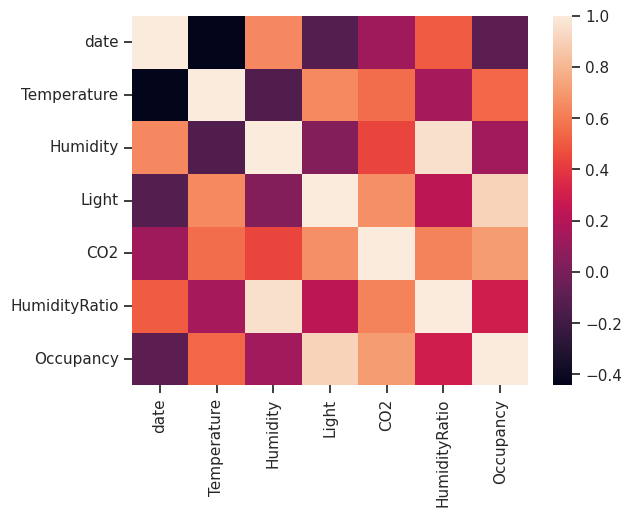

In [ ]:
# Тепловая карта
sns.heatmap(df_copy.corr())

<Axes: >

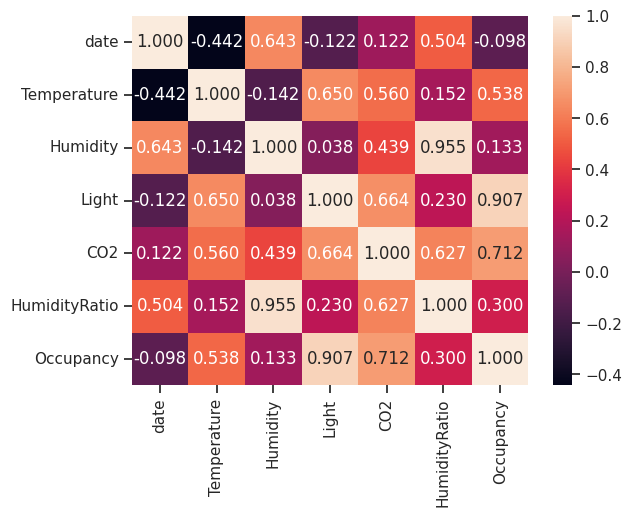

In [ ]:
# Вывод значений в ячейках
sns.heatmap(df_copy.corr(), annot=True, fmt='.3f')

<Axes: >

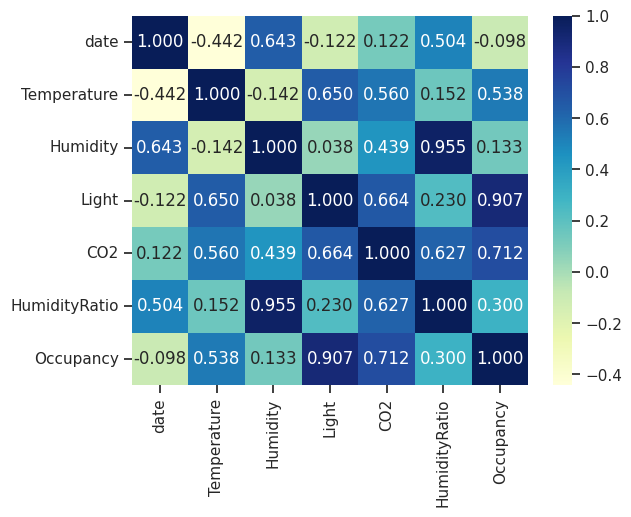

In [ ]:
# Изменение цветовой гаммы
sns.heatmap(df_copy.corr(), cmap='YlGnBu', annot=True, fmt='.3f')

1. Самые сильные корреляции

**Light и Occupancy (0.907)**

Интерпретация: Очень сильная прямая связь. Это абсолютно логично: когда в помещении есть люди (Occupancy=1), они обычно включают свет. Это один из ключевых признаков для прогнозирования occupancy.

**Humidity и HumidityRatio (0.955)**

Интерпретация: Почти полная прямая связь. Это ожидаемо, так как оба признака описывают влажность. Humidity — это относительная влажность, а HumidityRatio — абсолютное влагосодержание. Они физически тесно связаны. Важный вывод: Использовать оба этих признака вместе в одной модели (например, для линейной регрессии) может быть избыточно и вызвать проблему мультиколлинеарности. Часто один из них можно удалить.

**Light и CO2 (0.664)**

Интерпретация: Умеренно сильная прямая связь. Объясняется через общий фактор — наличие людей. Люди включают свет и выдыхают CO2.

**CO2 и Occupancy (0.712)**

Интерпретация: Сильная прямая связь. Чем больше людей в помещении, тем выше уровень CO2. Еще один ключевой признак для определения occupancy.

**Light и Temperature (0.650)**

Интерпретация: Умеренная прямая связь. Возможно, работающие светильники немного нагревают воздух, или же есть сезонная зависимость (зимой темнее и холоднее, но свет включают раньше).

2. Анализ целевой переменной (предполагаем, что это Occupancy)
Если ваша задача — предсказать, занято ли помещение, смотрите на последний столбец/строку.

Сильные связи с Occupancy:

1. Light (0.907) — самый важный признак

2. CO2 (0.712) — второй по важности признак

3. Temperature (0.538) — умеренная связь (возможно, люди влияют на температуру)

Слабые связи с Occupancy:

1. Humidity (0.133) — очень слабая

2. HumidityRatio (0.300) — слабая

3. date (-0.098) — практически отсутствует

**Вывод для прогнозирования Occupancy: модель будет сильно опираться на Light и CO2.**




-----------------------------------------------------------------------------------------------------------------------------------

In [ ]:
import os

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lava18/google-play-store-apps")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'google-play-store-apps' dataset.
Path to dataset files: /kaggle/input/google-play-store-apps


In [ ]:
main_file_path = os.path.join(path, 'googleplaystore.csv')

In [ ]:
df = pd.read_csv(main_file_path, sep = ',')

In [ ]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [ ]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [ ]:
df['Type'].unique() #посмотреть кол-во нулей + one hot encoding

array(['Free', 'Paid', nan, '0'], dtype=object)

In [ ]:
df['Reviews'].unique() #перевести строки в числа

array(['159', '967', '87510', ..., '603', '1195', '398307'], dtype=object)

In [ ]:
df['Size'].unique() #подумать что сделать с буквами все перевести в одно измерение

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [ ]:
df['Installs'].unique() #убрать "+", посмотреть что за 'Free', кол-во 0

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0', 'Free'], dtype=object)

In [ ]:
df['Price'].unique() #убрать знак $

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', 'Everyone', '$1.20', '$1.04'], dtype=object)

In [ ]:
df['Content Rating'].unique()

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated', nan], dtype=object)

In [ ]:
df['Genres'].unique() #??? onehotencoding - слишком сильно расширим таблицу, label - нет порядка и тоже много разных значений ???????????? Frequence

array(['Art & Design', 'Art & Design;Pretend Play',
       'Art & Design;Creativity', 'Art & Design;Action & Adventure',
       'Auto & Vehicles', 'Beauty', 'Books & Reference', 'Business',
       'Comics', 'Comics;Creativity', 'Communication', 'Dating',
       'Education;Education', 'Education', 'Education;Creativity',
       'Education;Music & Video', 'Education;Action & Adventure',
       'Education;Pretend Play', 'Education;Brain Games', 'Entertainment',
       'Entertainment;Music & Video', 'Entertainment;Brain Games',
       'Entertainment;Creativity', 'Events', 'Finance', 'Food & Drink',
       'Health & Fitness', 'House & Home', 'Libraries & Demo',
       'Lifestyle', 'Lifestyle;Pretend Play',
       'Adventure;Action & Adventure', 'Arcade', 'Casual', 'Card',
       'Casual;Pretend Play', 'Action', 'Strategy', 'Puzzle', 'Sports',
       'Music', 'Word', 'Racing', 'Casual;Creativity',
       'Casual;Action & Adventure', 'Simulation', 'Adventure', 'Board',
       'Trivia', 'Role 

In [ ]:
df['Last Updated'].unique()  #перевести в тип дата

array(['January 7, 2018', 'January 15, 2018', 'August 1, 2018', ...,
       'January 20, 2014', 'February 16, 2014', 'March 23, 2014'],
      dtype=object)

In [ ]:
df['Current Ver'].unique() #убрать точки???? во что перевести ???????????????

array(['1.0.0', '2.0.0', '1.2.4', ..., '1.0.612928', '0.3.4', '2.0.148.0'],
      dtype=object)

In [ ]:
df['Android Ver'].unique()

array(['4.0.3 and up', '4.2 and up', '4.4 and up', '2.3 and up',
       '3.0 and up', '4.1 and up', '4.0 and up', '2.3.3 and up',
       'Varies with device', '2.2 and up', '5.0 and up', '6.0 and up',
       '1.6 and up', '1.5 and up', '2.1 and up', '7.0 and up',
       '5.1 and up', '4.3 and up', '4.0.3 - 7.1.1', '2.0 and up',
       '3.2 and up', '4.4W and up', '7.1 and up', '7.0 - 7.1.1',
       '8.0 and up', '5.0 - 8.0', '3.1 and up', '2.0.1 and up',
       '4.1 - 7.1.1', nan, '5.0 - 6.0', '1.0 and up', '2.2 - 7.1.1',
       '5.0 - 7.1.1'], dtype=object)

In [ ]:
df['App'].unique()

array(['Photo Editor & Candy Camera & Grid & ScrapBook',
       'Coloring book moana',
       'U Launcher Lite – FREE Live Cool Themes, Hide Apps', ...,
       'Parkinson Exercices FR', 'The SCP Foundation DB fr nn5n',
       'iHoroscope - 2018 Daily Horoscope & Astrology'], dtype=object)

In [ ]:
# Определим уникальные значения для целевого признака
df['Rating'].unique()

array([ 4.1,  3.9,  4.7,  4.5,  4.3,  4.4,  3.8,  4.2,  4.6,  3.2,  4. ,
        nan,  4.8,  4.9,  3.6,  3.7,  3.3,  3.4,  3.5,  3.1,  5. ,  2.6,
        3. ,  1.9,  2.5,  2.8,  2.7,  1. ,  2.9,  2.3,  2.2,  1.7,  2. ,
        1.8,  2.4,  1.6,  2.1,  1.4,  1.5,  1.2, 19. ])

Целевая переменная Rating

In [ ]:
df.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,object
Size,object
Installs,object
Type,object
Price,object
Content Rating,object
Genres,object


In [ ]:
df.shape

(10841, 13)

In [ ]:
df.isnull().sum() # много пропустов в Rating(я бы заполнила средним значением), незначительные пропуски в Type(1), Content rating(1), current Ver(8), Android Ver (3) эти бы заполнила нулями

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [ ]:
df.describe() # только 1 столюец числовой - Рейтинг, нужно преобразовывать даные в числовой формат

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


<Axes: xlabel='Rating', ylabel='Reviews'>

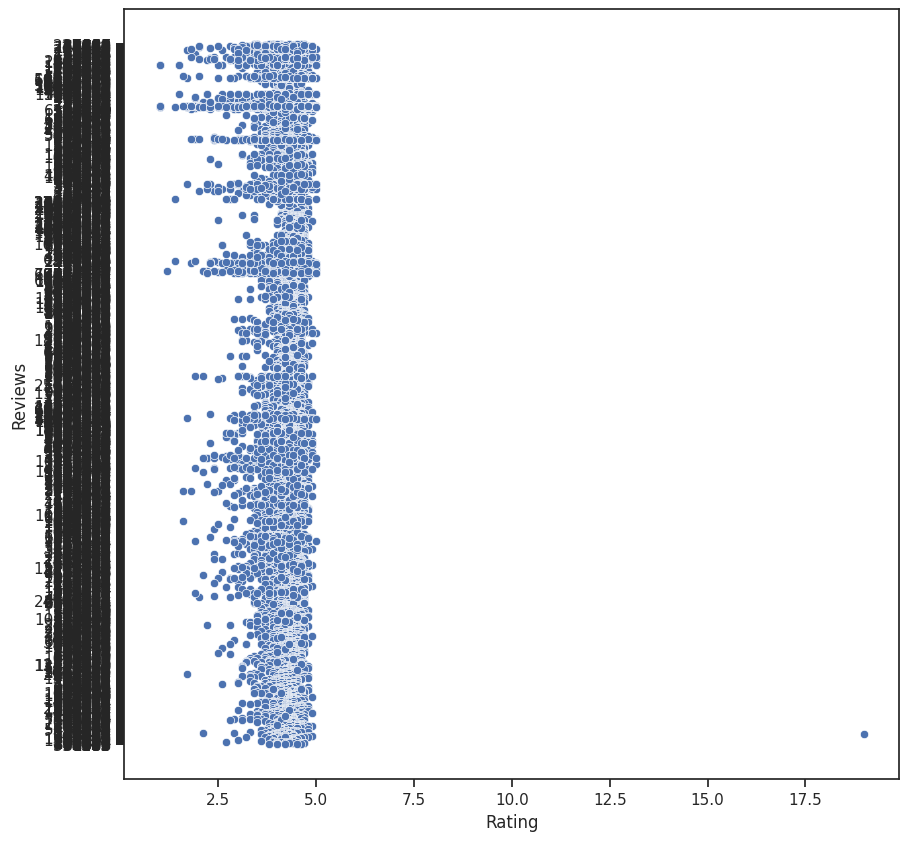

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(ax=ax, x='Rating', y='Reviews', data=df)

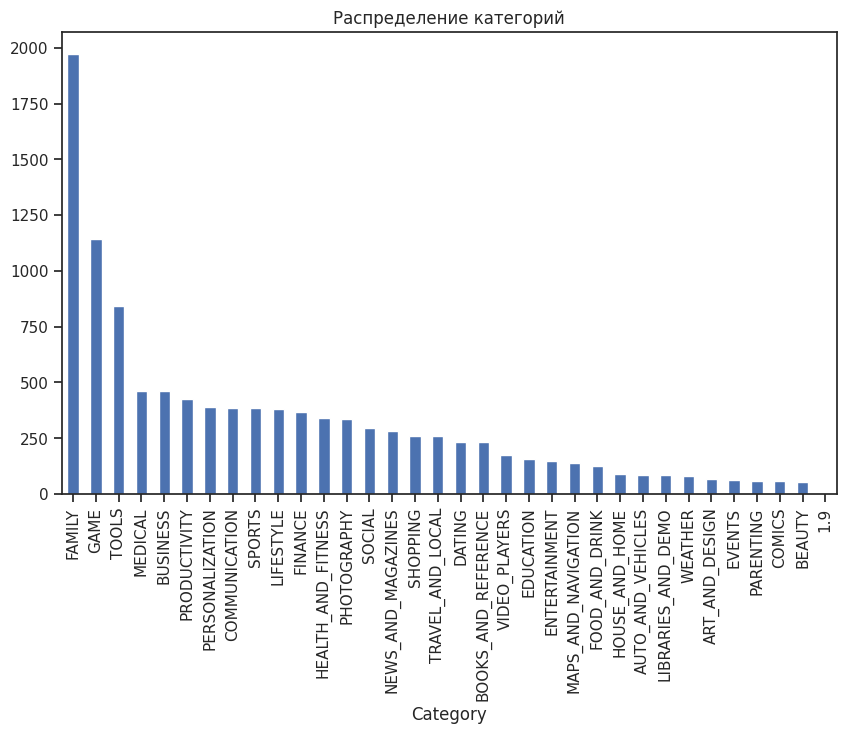

In [ ]:
plt.figure(figsize=(10, 6))
df['Category'].value_counts().plot(kind='bar')
plt.title('Распределение категорий')
plt.show()


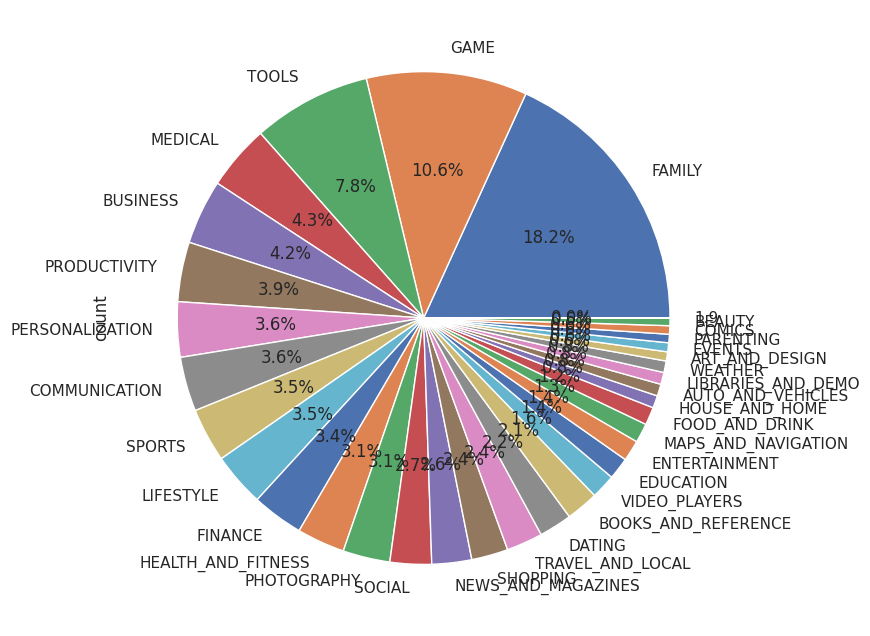

In [ ]:
# Круговые диаграммы
plt.figure(figsize=(8, 8))
df['Category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

In [ ]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

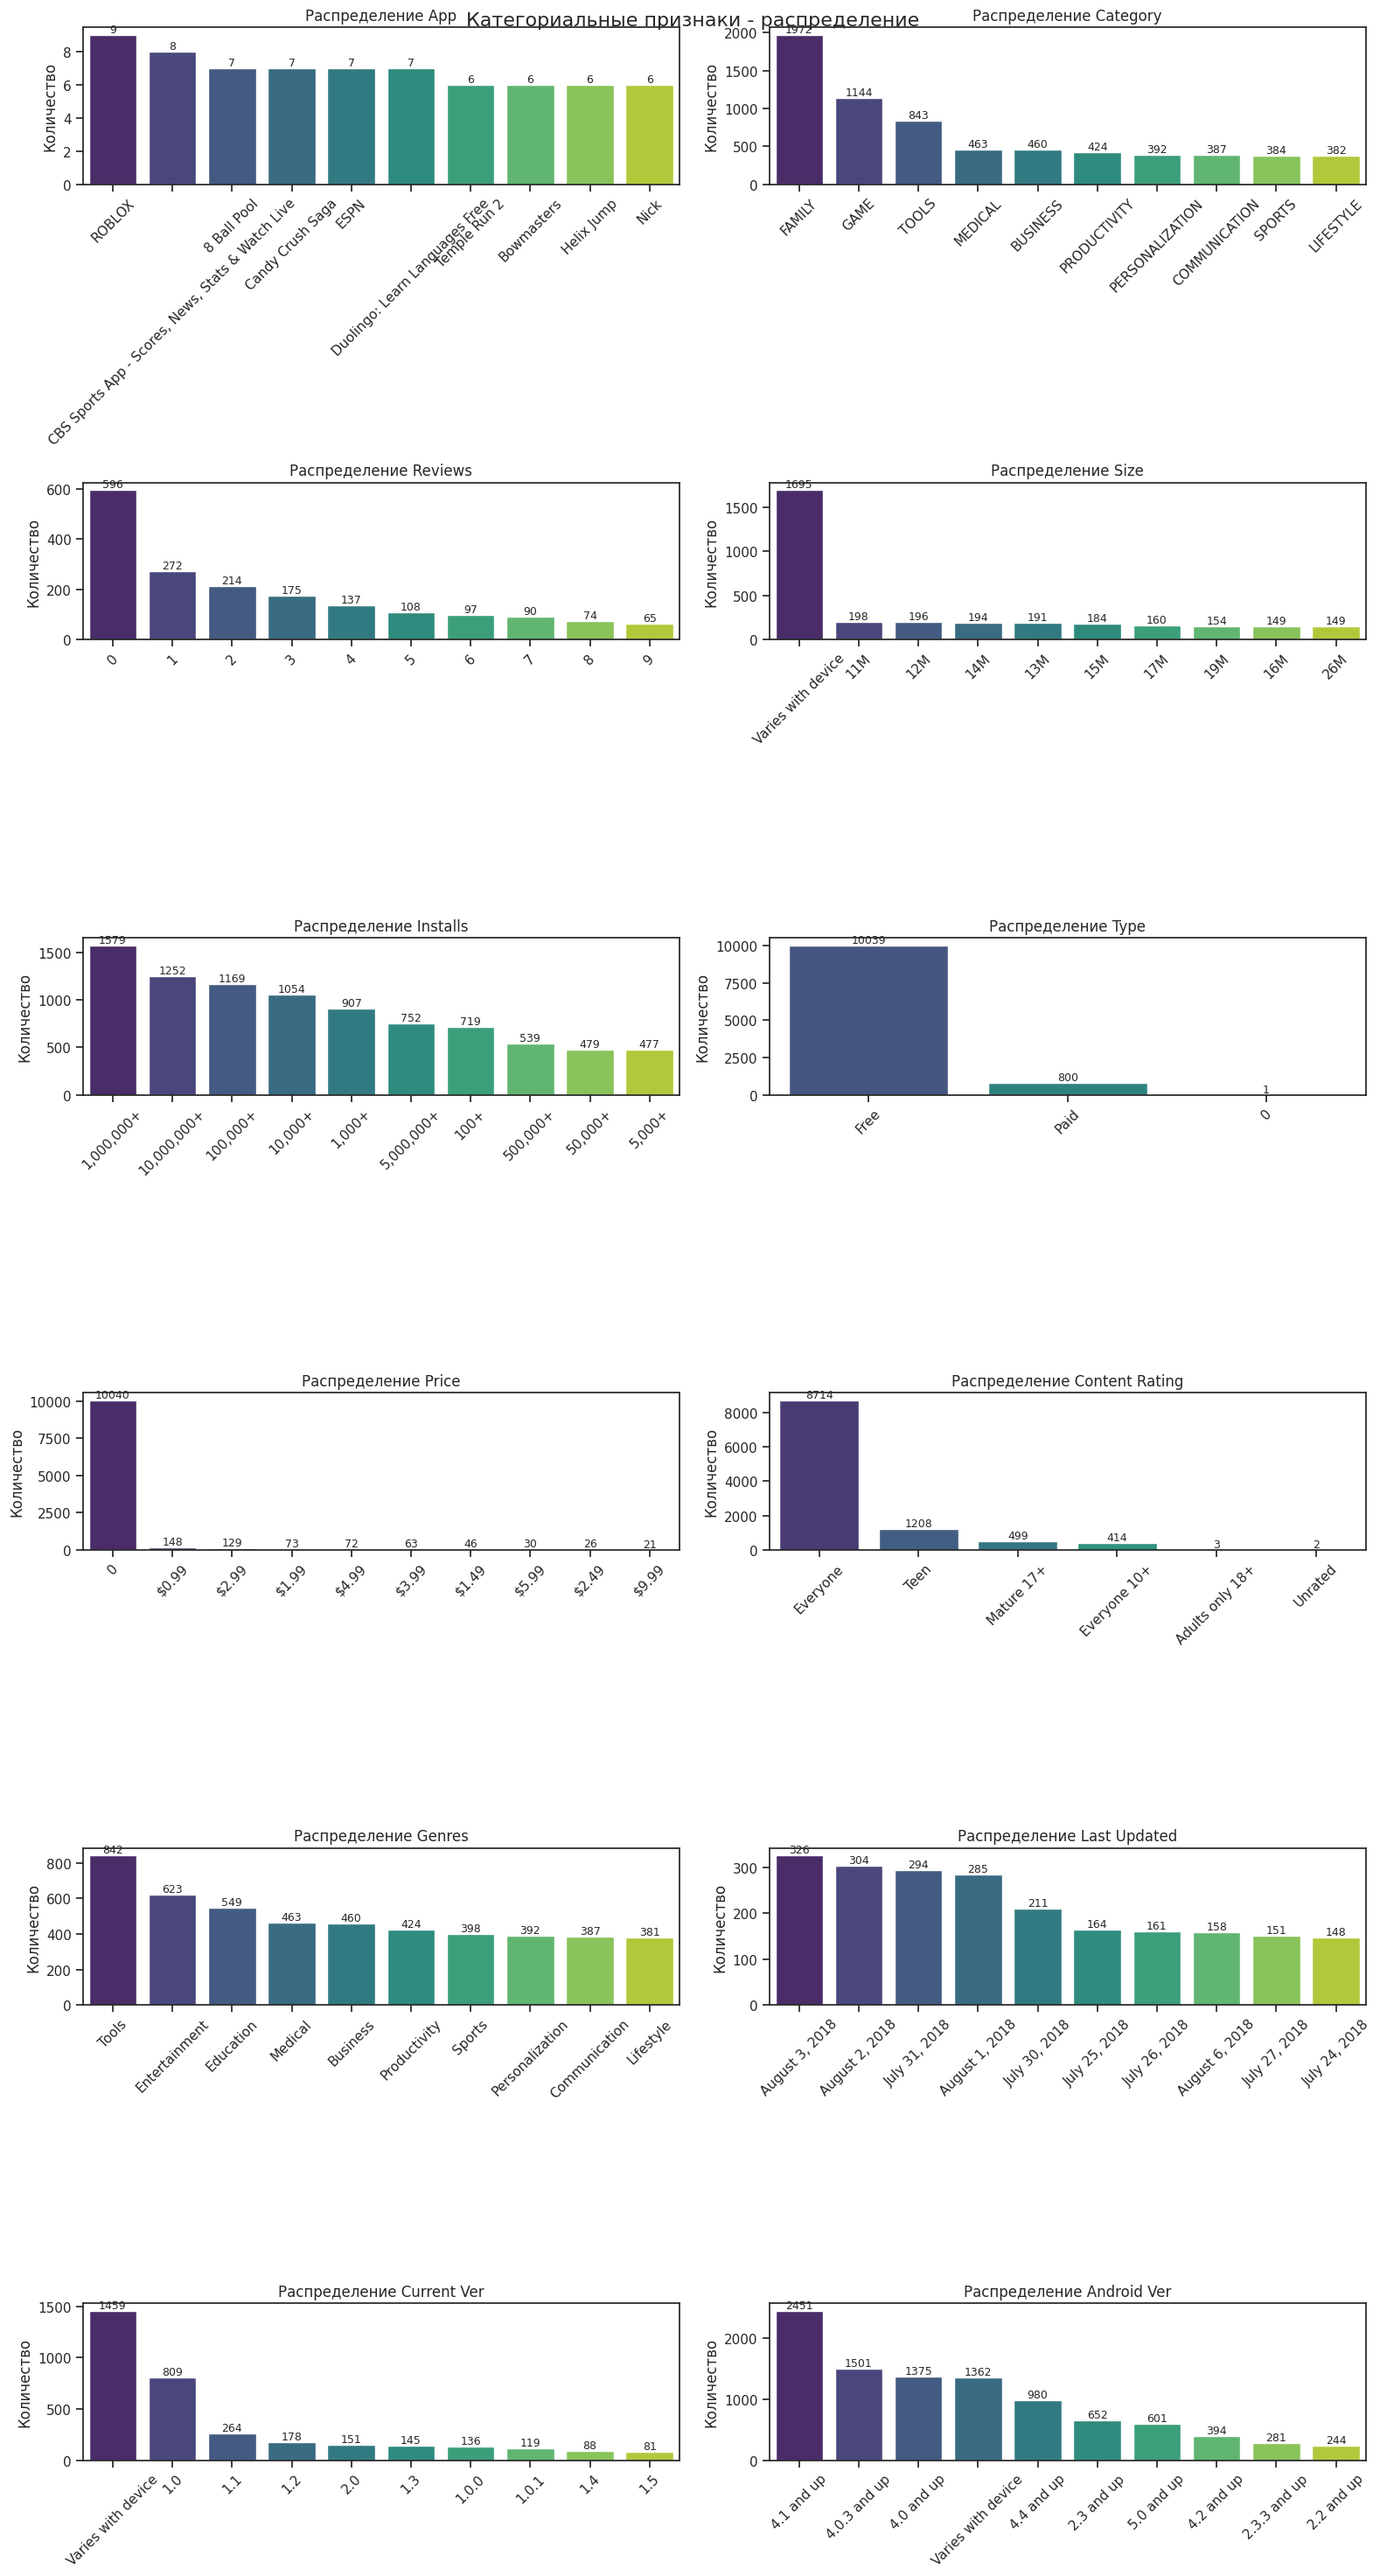

In [ ]:
n_cols = 2
n_rows = (len(categorical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes]

for i, col in enumerate(categorical_columns):
    if i < len(axes):
        # Получаем топ категорий
        top_categories = df[col].value_counts().head(10)

        # добавляем hue и legend=False
        sns.barplot(x=top_categories.index, y=top_categories.values,
                   ax=axes[i], hue=top_categories.index, legend=False, palette='viridis')

        axes[i].set_title(f'Распределение {col}')
        axes[i].set_ylabel('Количество')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)

        # Добавляем аннотации
        for p in axes[i].patches:
            axes[i].annotate(f'{int(p.get_height())}',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', fontsize=9)

# Скрываем пустые subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Категориальные признаки - распределение', fontsize=16)
plt.tight_layout()
plt.show()